# Learning to classically simulate RCS from samples

## Parameters

In [1]:
# Experiment parameters.
N_VALUES = [32]  # Number of qubits.

# Circuit parameters.
CZ_DEPTH = 10
SEED     = 42

# Model parameters/options.
USE_PT_REGULARISATION = True   # Set True to penalise non-Porter-Thomas distributions.
LAMBDA_PT             = 0.01     # Regularisation strength (only used if above is True).

# Training parameters.
BATCH_SIZE   = 512
TOTAL_STEPS  = 50_000   # fixed gradient-step budget for all N_train sizes
MIN_EPOCHS   = 50       # always do at least this many epochs regardless of dataset size
MAX_EPOCHS   = 5_000    # cap for tiny datasets to keep runtime sane
N_TEST_OVERLAP = 10_000  # samples used for overlap / generalisation diagnostics


## Setup

### Imports

In [2]:
import numpy as np
import torch
import cirq
import matplotlib.pyplot as plt

from aics.models import AutoregressiveRNN, AutoregressiveTransformer
from aics.circuits import make_boixo_v2_rcs_circuit
from aics.circuits.boixo_v2 import grid_dimensions
from aics.eval.xeb import linear_xeb as xeb_fidelity
from aics.io.conventions import bits_to_int as bitstrings_to_indices
from aics.training.nll import train_nll

### Seed and device

In [3]:
torch.manual_seed(0)
np.random.seed(0)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE

'cuda'

### Circuit definition

In [4]:
def generate_rcs_grid(n_qubits: int, cz_depth: int, seed: int) -> cirq.Circuit:
    """Google v2 RCS circuit (Boixo et al. 2018)."""
    _, circuit = make_boixo_v2_rcs_circuit(n_qubits, depth=cz_depth, seed=seed)
    return circuit

### Circuit simulation functions

In [5]:
def simulate_circuit(circuit: cirq.Circuit) -> np.ndarray:
    """Return exact probability distribution over all 2^n bitstrings."""
    sv    = cirq.Simulator().simulate(circuit).final_state_vector
    probs = np.abs(sv) ** 2
    return probs / probs.sum()

def index_to_bitstring(idx: int, n_bits: int) -> np.ndarray:
    """Integer index → binary array, MSB first."""
    return np.array([(idx >> (n_bits - 1 - i)) & 1 for i in range(n_bits)], dtype=np.float32)

def kl_divergence(model_probs: np.ndarray, true_probs: np.ndarray, eps: float = 1e-12) -> float:
    """KL(true || model). Only feasible for small n."""
    return float(np.sum(true_probs * np.log((true_probs + eps) / (model_probs + eps))))

def sample_bitstrings(probs: np.ndarray, n_bits: int, n_samples: int, seed: int = None) -> np.ndarray:
    """Draw n_samples bitstrings from distribution probs."""
    rng = np.random.default_rng(seed)
    idx = rng.choice(len(probs), size=n_samples, p=probs)
    return np.stack([index_to_bitstring(i, n_bits) for i in idx])

### Autoregressive RNN Model

Models $p(x) = p(x_1) · p(x_2|x_1) \cdots p(x_n|x_1,…,x_{n - 1})$ via a two-layer LSTM.

In [6]:
def train_rnn(n_bits, probs, n_train, total_steps=TOTAL_STEPS, min_epochs=MIN_EPOCHS, max_epochs=MAX_EPOCHS, hidden=128, seed=1):
    """
    Train a fresh RNN with a fixed gradient-step budget.

    Metrics returned:
      xeb_model    : XEB of model-generated samples (existing metric)
      xeb_gen      : Generalisation XEB — model probabilities scored on
                     held-out quantum samples the model never saw.
                     F_gen = N * <q(z)>_{z ~ p_U} - 1
                     where q is the model distribution, z are fresh quantum samples.
                     This is the correct test of whether the model has learned p_U,
                     not just memorised the training set.
      kl           : KL(true || model), only for n_bits <= 16
    """
    torch.manual_seed(seed); np.random.seed(seed)

    # Training samples (seed=seed) and held-out test samples (seed=seed+999)
    n_states   = len(probs)
    train_bits = sample_bitstrings(probs, n_bits, n_train,   seed=seed)
    test_bits  = sample_bitstrings(probs, n_bits, 10_000,    seed=seed + 999)

    model = AutoregressiveRNN(n_bits=n_bits, hidden=hidden).to(DEVICE)
    lam = LAMBDA_PT if USE_PT_REGULARISATION else 0.0
    final_nll, n_epochs, losses = train_nll(
        model, train_bits,
        total_steps=total_steps, min_epochs=min_epochs, max_epochs=max_epochs,
        batch_size=BATCH_SIZE, lr=1e-3, lambda_pt=lam,
        n_states=n_states, device=DEVICE,
    )

    model.eval()

    # XEB of model-generated samples (original metric)
    model_samples = model.sample_bits(10_000)
    xeb_model     = xeb_fidelity(model_samples, probs)

    # Generalisation XEB: score model probabilities on held-out quantum samples
    # F_gen = N * <q(z)>_{z ~ p_U} - 1  where q(z) = model probability of z
    test_t        = torch.tensor(test_bits, device=DEVICE)
    with torch.no_grad():
        log_q     = model.log_prob(test_t).cpu().numpy()
    q_probs       = np.exp(log_q)                        # model prob of each test bitstring
    xeb_gen       = float(len(probs) * q_probs.mean() - 1)

    kl = None
    if n_bits <= 16:
        kl = kl_divergence(model.full_distribution(len(probs), n_bits), probs)

    return {'n_bits': n_bits, 'n_train': n_train, 'n_epochs': n_epochs,
            'xeb_model': xeb_model, 'xeb_gen': xeb_gen,
            'kl': kl, 'final_nll': final_nll, 'losses': losses,
            '_model_samples': model_samples,   # kept for diagnostics, not logged
            '_train_bits':    train_bits,
            '_test_bits':     test_bits}

def generalisation_report(res: dict, probs: np.ndarray) -> dict:
    """
    Quantify memorisation vs generalisation using three sample sets:
      - train set  : bitstrings the model trained on
      - test set   : fresh quantum samples, never seen by model  (z ~ p_U)
      - model set  : fresh samples generated by the trained model (z ~ q)

    Key comparisons:
      overlap(model, train) high + overlap(model, test) low  → memorisation
      overlap(model, test)  comparable to overlap(test, test) → generalisation
    """
    from collections import Counter

    train_bits    = res['_train_bits']
    test_bits     = res['_test_bits']
    model_samples = res['_model_samples']

    train_idx = set(bitstrings_to_indices(train_bits).tolist())
    test_idx  = bitstrings_to_indices(test_bits).tolist()
    model_idx = bitstrings_to_indices(model_samples).tolist()

    n_model = len(model_idx)

    # Overlap: fraction of model samples that appear in train / test sets
    overlap_train = sum(1 for i in model_idx if i in train_idx) / n_model
    test_idx_set  = set(test_idx)
    overlap_test  = sum(1 for i in model_idx if i in test_idx_set) / n_model

    # Baseline: how much does the test set overlap with itself (sample from same dist)?
    # Expected ~ 1 - (1 - 1/|support|)^|test| ≈ |test|/|support| for large support
    half      = test_idx[:len(test_idx)//2]
    other     = set(test_idx[len(test_idx)//2:])
    overlap_test_self = sum(1 for i in half if i in other) / len(half)

    # Diversity: unique bitstrings in model samples
    n_unique_model = len(set(model_idx))
    top1_pct       = 100 * Counter(model_idx).most_common(1)[0][1] / n_model

    report = {
        'overlap_train':     overlap_train,
        'overlap_test':      overlap_test,
        'overlap_test_self': overlap_test_self,
        'n_unique_model':    n_unique_model,
        'top1_pct':          top1_pct,
    }

    # Verdict
    if overlap_train > 0.5 and overlap_test < overlap_test_self * 0.5:
        verdict = '⚠ MEMORISATION'
    elif overlap_test >= overlap_test_self * 0.5 and overlap_train < 0.5:
        verdict = '✓ GENERALISATION'
    elif overlap_train > 0.3:
        verdict = '~ PARTIAL MEMORISATION'
    else:
        verdict = '~ INCONCLUSIVE'
    report['verdict'] = verdict

    return report

### Autoregressive Transformer Model

Same factorisation as the RNN above, $p(x) = p(x_1) \cdot p(x_2|x_1) \cdots p(x_n|x_1,\ldots,x_{n-1})$, but modelled with a causal self-attention encoder instead of an LSTM. Trained with the exact same `train_nll` loop, PT regularisation, and metrics, so `xeb_gen` / `kl` are directly comparable to the RNN's.

In [7]:
def train_transformer(n_bits, probs, n_train, total_steps=TOTAL_STEPS, min_epochs=MIN_EPOCHS, max_epochs=MAX_EPOCHS, d_model=128, n_layers=2, n_heads=4, seed=1):
    """
    Train a fresh Transformer with a fixed gradient-step budget. Mirrors
    train_rnn exactly (same NLL trainer, same metrics, same seeding) so the
    only difference between the two result sets is the architecture.
    """
    torch.manual_seed(seed); np.random.seed(seed)

    # Training samples (seed=seed) and held-out test samples (seed=seed+999)
    n_states   = len(probs)
    train_bits = sample_bitstrings(probs, n_bits, n_train,   seed=seed)
    test_bits  = sample_bitstrings(probs, n_bits, 10_000,    seed=seed + 999)

    model = AutoregressiveTransformer(n_bits=n_bits, d_model=d_model, n_layers=n_layers, n_heads=n_heads).to(DEVICE)
    lam = LAMBDA_PT if USE_PT_REGULARISATION else 0.0
    final_nll, n_epochs, losses = train_nll(
        model, train_bits,
        total_steps=total_steps, min_epochs=min_epochs, max_epochs=max_epochs,
        batch_size=BATCH_SIZE, lr=1e-3, lambda_pt=lam,
        n_states=n_states, device=DEVICE,
    )

    model.eval()

    # XEB of model-generated samples (original metric)
    model_samples = model.sample_bits(10_000)
    xeb_model     = xeb_fidelity(model_samples, probs)

    # Generalisation XEB: score model probabilities on held-out quantum samples
    test_t        = torch.tensor(test_bits, device=DEVICE)
    with torch.no_grad():
        log_q     = model.log_prob(test_t).cpu().numpy()
    q_probs       = np.exp(log_q)
    xeb_gen       = float(len(probs) * q_probs.mean() - 1)

    kl = None
    if n_bits <= 16:
        kl = kl_divergence(model.full_distribution(len(probs), n_bits), probs)

    return {'n_bits': n_bits, 'n_train': n_train, 'n_epochs': n_epochs,
            'xeb_model': xeb_model, 'xeb_gen': xeb_gen,
            'kl': kl, 'final_nll': final_nll, 'losses': losses,
            '_model_samples': model_samples,   # kept for diagnostics, not logged
            '_train_bits':    train_bits,
            '_test_bits':     test_bits}

## Experiment

In [ ]:
n_sweep_results = []
for nqubits in N_VALUES:
    print("Status: On nqubits =", nqubits)

    # Build circuit and simulate
    circuit_n = generate_rcs_grid(nqubits, CZ_DEPTH, SEED)
    probs_n   = simulate_circuit(circuit_n)
    n_states_n = len(probs_n)

    # Baselines for this n
    xeb_ideal_n  = xeb_fidelity(sample_bitstrings(probs_n, nqubits, 10_000), probs_n)
    xeb_unif_n   = xeb_fidelity(np.random.randint(0,2,(10_000,nqubits)).astype(np.float32), probs_n)
    print(f"Grid: {grid_dimensions(nqubits)} | Ideal XEB: {xeb_ideal_n:.4f} | Uniform XEB: {xeb_unif_n:.4f}")

    sweep_sizes_n = sorted(set([
        nqubits ** 2,
        int(nqubits ** 2 * np.log2(nqubits)),
        nqubits ** 3,
        int(nqubits ** 3 * np.log2(nqubits)),
        10_000,
        100_000,
        # 1_000_000,
    ]))

    for n_train in sweep_sizes_n:
        res = train_rnn(nqubits, probs_n, n_train=n_train)
        res.update({'xeb_ideal': xeb_ideal_n, 'xeb_unif': xeb_unif_n})
        n_sweep_results.append(res)
        kl_str = f'KL={res["kl"]:.4f}' if res['kl'] is not None else 'KL=N/A'
        print(f"N_train={n_train:>6,} ...  XEB_model={res['xeb_model']:+.4f}  XEB_gen={res['xeb_gen']:+.4f}  {kl_str}")
        gr = generalisation_report(res, probs_n)
        print(f"overlap(model,train)={gr['overlap_train']:.3f}  overlap(model,test)={gr['overlap_test']:.3f}  overlap(test,test)={gr['overlap_test_self']:.3f}  unique={gr['n_unique_model']:,}  top1={gr['top1_pct']:.1f}%  {gr['verdict']}")

Status: On nqubits = 32


In [ ]:
n_sweep_results_transformer = []
for nqubits in N_VALUES:
    print("Status: On nqubits =", nqubits)

    # Build circuit and simulate
    circuit_n = generate_rcs_grid(nqubits, CZ_DEPTH, SEED)
    probs_n   = simulate_circuit(circuit_n)
    n_states_n = len(probs_n)

    # Baselines for this n
    xeb_ideal_n  = xeb_fidelity(sample_bitstrings(probs_n, nqubits, 10_000), probs_n)
    xeb_unif_n   = xeb_fidelity(np.random.randint(0,2,(10_000,nqubits)).astype(np.float32), probs_n)
    print(f"Grid: {grid_dimensions(nqubits)} | Ideal XEB: {xeb_ideal_n:.4f} | Uniform XEB: {xeb_unif_n:.4f}")

    sweep_sizes_n = sorted(set([
        nqubits ** 2,
        int(nqubits ** 2 * np.log2(nqubits)),
        nqubits ** 3,
        int(nqubits ** 3 * np.log2(nqubits)),
        10_000,
        100_000,
        # 1_000_000,
    ]))

    for n_train in sweep_sizes_n:
        res = train_transformer(nqubits, probs_n, n_train=n_train)
        res.update({'xeb_ideal': xeb_ideal_n, 'xeb_unif': xeb_unif_n})
        n_sweep_results_transformer.append(res)
        kl_str = f'KL={res["kl"]:.4f}' if res['kl'] is not None else 'KL=N/A'
        print(f"N_train={n_train:>6,} ...  XEB_model={res['xeb_model']:+.4f}  XEB_gen={res['xeb_gen']:+.4f}  {kl_str}")
        gr = generalisation_report(res, probs_n)
        print(f"overlap(model,train)={gr['overlap_train']:.3f}  overlap(model,test)={gr['overlap_test']:.3f}  overlap(test,test)={gr['overlap_test_self']:.3f}  unique={gr['n_unique_model']:,}  top1={gr['top1_pct']:.1f}%  {gr['verdict']}")

Status: On nqubits = 12
Grid: (2, 6) | Ideal XEB: 0.9580 | Uniform XEB: -0.0025


/home/lonelyneutrin0/Repos/AIForCircuitSampling/venv/lib/python3.12/site-packages/aics/models/autoregressive_transformer.py:23: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)
W0805 23:42:28.072000 158343 torch/_inductor/utils.py:1953] [1/0] Not enough SMs to use max_autotune_gemm mode


N_train=   144 ...  XEB_model=+1.0494  XEB_gen=+1.1506  KL=17.0802
overlap(model,train)=1.000  overlap(model,test)=0.937  overlap(test,test)=0.807  unique=142  top1=1.1%  ~ PARTIAL MEMORISATION


/home/lonelyneutrin0/Repos/AIForCircuitSampling/venv/lib/python3.12/site-packages/aics/models/autoregressive_transformer.py:23: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)


N_train=   516 ...  XEB_model=+0.8785  XEB_gen=+0.9253  KL=12.1686
overlap(model,train)=1.000  overlap(model,test)=0.922  overlap(test,test)=0.807  unique=465  top1=0.5%  ~ PARTIAL MEMORISATION


...

N_train= 1,728 ...  XEB_model=+0.9469  XEB_gen=+0.9495  KL=5.3941
overlap(model,train)=0.999  overlap(model,test)=0.921  overlap(test,test)=0.807  unique=1,238  top1=0.3%  ~ PARTIAL MEMORISATION
N_train= 6,194 ...  XEB_model=+0.9482  XEB_gen=+0.9521  KL=1.3085
overlap(model,train)=0.993  overlap(model,test)=0.914  overlap(test,test)=0.807  unique=2,320  top1=0.3%  ~ PARTIAL MEMORISATION
N_train=10,000 ...  XEB_model=+0.9525  XEB_gen=+0.9587  KL=0.6659
overlap(model,train)=0.999  overlap(model,test)=0.915  overlap(test,test)=0.807  unique=2,525  top1=0.2%  ~ PARTIAL MEMORISATION
N_train=100,000 ...  XEB_model=+0.9331  XEB_gen=+0.9559  KL=0.0239
overlap(model,train)=0.999  overlap(model,test)=0.910  overlap(test,test)=0.807  unique=2,892  top1=0.2%  ~ PARTIAL MEMORISATION
Status: On nqubits = 16
Grid: (2, 8) | Ideal XEB: 1.4501 | Uniform XEB: -0.0125


/home/lonelyneutrin0/Repos/AIForCircuitSampling/venv/lib/python3.12/site-packages/aics/models/autoregressive_transformer.py:23: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)


N_train=   256 ...  XEB_model=+0.6325  XEB_gen=+0.6891  KL=10.6145
overlap(model,train)=0.397  overlap(model,test)=0.219  overlap(test,test)=0.160  unique=2,474  top1=0.3%  ✓ GENERALISATION


/home/lonelyneutrin0/Repos/AIForCircuitSampling/venv/lib/python3.12/site-packages/aics/models/autoregressive_transformer.py:23: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, num_layers=n_layers)


N_train= 1,024 ...  XEB_model=+1.5692  XEB_gen=+1.4550  KL=15.5649
overlap(model,train)=0.999  overlap(model,test)=0.281  overlap(test,test)=0.160  unique=1,008  top1=0.2%  ~ PARTIAL MEMORISATION
N_train= 4,096 ...  XEB_model=+1.4215  XEB_gen=+1.3692  KL=12.1580
overlap(model,train)=0.999  overlap(model,test)=0.275  overlap(test,test)=0.160  unique=3,509  top1=0.1%  ~ PARTIAL MEMORISATION
N_train=10,000 ...  XEB_model=+1.4177  XEB_gen=+1.3897  KL=7.2940
overlap(model,train)=0.995  overlap(model,test)=0.281  overlap(test,test)=0.160  unique=5,721  top1=0.1%  ~ PARTIAL MEMORISATION
N_train=16,384 ...  XEB_model=+1.4061  XEB_gen=+1.3978  KL=5.0009
overlap(model,train)=0.982  overlap(model,test)=0.279  overlap(test,test)=0.160  unique=6,578  top1=0.1%  ~ PARTIAL MEMORISATION
N_train=100,000 ...  XEB_model=+1.1740  XEB_gen=+1.1697  KL=0.3533
overlap(model,train)=0.865  overlap(model,test)=0.251  overlap(test,test)=0.160  unique=8,343  top1=0.1%  ~ PARTIAL MEMORISATION


In [ ]:
import pickle
from pathlib import Path

# Raw sweep results (including per-run samples/losses) for both architectures,
# so the comparison can be replotted later without rerunning training.
RESULTS_DIR = Path("../results/rnn_vs_transformer")
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

with open(RESULTS_DIR / "rnn_sweep_results.pkl", "wb") as f:
    pickle.dump(n_sweep_results, f)
with open(RESULTS_DIR / "transformer_sweep_results.pkl", "wb") as f:
    pickle.dump(n_sweep_results_transformer, f)

print(f"Saved {len(n_sweep_results)} RNN results and "
      f"{len(n_sweep_results_transformer)} Transformer results to {RESULTS_DIR}/")

Saved 12 RNN results and 12 Transformer results to ../results/rnn_vs_transformer/


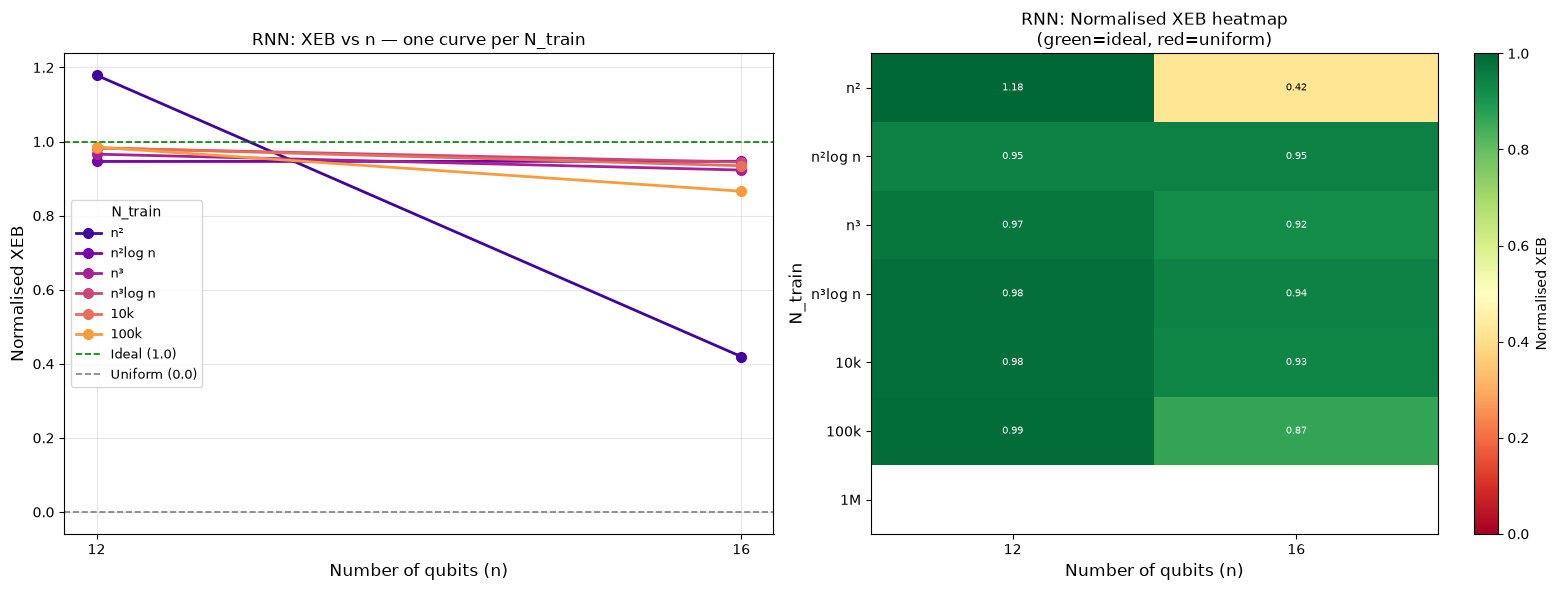

In [ ]:
import pandas as pd

train_labels = ['n²', 'n²log n', 'n³', 'n³log n', '10k', '100k', '1M']

def poly_label(n_train, n):
    opts = {
        n**2:                    'n²',
        int(n**2 * np.log2(n)): 'n²log n',
        n**3:                    'n³',
        int(n**3 * np.log2(n)): 'n³log n',
        10_000:                  '10k',
        100_000:                 '100k',
        1_000_000:               '1M',
    }
    return opts.get(n_train, str(n_train))

def build_sweep_df(results):
    df = pd.DataFrame(results)
    # Normalised XEB: 0=uniform, 1=ideal
    # Two normalised metrics
    df['xeb_model_norm'] = (df['xeb_model'] - df['xeb_unif']) / (df['xeb_ideal'] - df['xeb_unif'])
    df['xeb_gen_norm']   = (df['xeb_gen']   - df['xeb_unif']) / (df['xeb_ideal'] - df['xeb_unif'])
    # Primary metric for heatmap: generalisation XEB
    df['xeb_norm'] = df['xeb_gen_norm']
    return df

def plot_sweep(df, title_prefix, pdf_name):
    n_values = sorted(df['n_bits'].unique())
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    colors = plt.cm.plasma(np.linspace(0.1, 0.9, len(train_labels)))

    # ── Plot 1: XEB vs n, one curve per N_train label ─────────────────────
    for label, col in zip(train_labels, colors):
        xs, ys = [], []
        for n in n_values:
            sub = df[df['n_bits'] == n]
            for _, row in sub.iterrows():
                if poly_label(int(row['n_train']), n) == label:
                    xs.append(n); ys.append(row['xeb_norm']); break
        if xs:
            axes[0].plot(xs, ys, 'o-', color=col, lw=2, ms=7, label=label)

    axes[0].axhline(1.0, color='green', ls='--', lw=1.2, label='Ideal (1.0)')
    axes[0].axhline(0.0, color='grey',  ls='--', lw=1.2, label='Uniform (0.0)')
    axes[0].set_xlabel('Number of qubits (n)', fontsize=12)
    axes[0].set_ylabel('Normalised XEB', fontsize=12)
    axes[0].set_title(f'{title_prefix}: XEB vs n — one curve per N_train', fontsize=12)
    axes[0].legend(fontsize=9, title='N_train')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xticks(n_values)

    # Heatmap
    heatmap = np.full((len(train_labels), len(n_values)), np.nan)
    for j, n in enumerate(n_values):
        sub = df[df['n_bits'] == n]
        for i, label in enumerate(train_labels):
            for _, row in sub.iterrows():
                if poly_label(int(row['n_train']), n) == label:
                    heatmap[i, j] = row['xeb_norm']; break

    im = axes[1].imshow(heatmap, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1, origin='upper')
    axes[1].set_xticks(range(len(n_values)));     axes[1].set_xticklabels(n_values)
    axes[1].set_yticks(range(len(train_labels))); axes[1].set_yticklabels(train_labels)
    axes[1].set_xlabel('Number of qubits (n)', fontsize=12)
    axes[1].set_ylabel('N_train', fontsize=12)
    axes[1].set_title(f'{title_prefix}: Normalised XEB heatmap\n(green=ideal, red=uniform)', fontsize=12)
    plt.colorbar(im, ax=axes[1], label='Normalised XEB')
    for i in range(len(train_labels)):
        for j in range(len(n_values)):
            v = heatmap[i, j]
            if not np.isnan(v):
                axes[1].text(j, i, f'{v:.2f}', ha='center', va='center',
                             fontsize=7.5, color='black' if 0.2 < v < 0.8 else 'white')

    plt.tight_layout()
    plt.savefig(pdf_name)
    plt.show()

df_rnn = build_sweep_df(n_sweep_results)
plot_sweep(df_rnn, 'RNN', 'rnn_n_qubit_sweep.pdf')

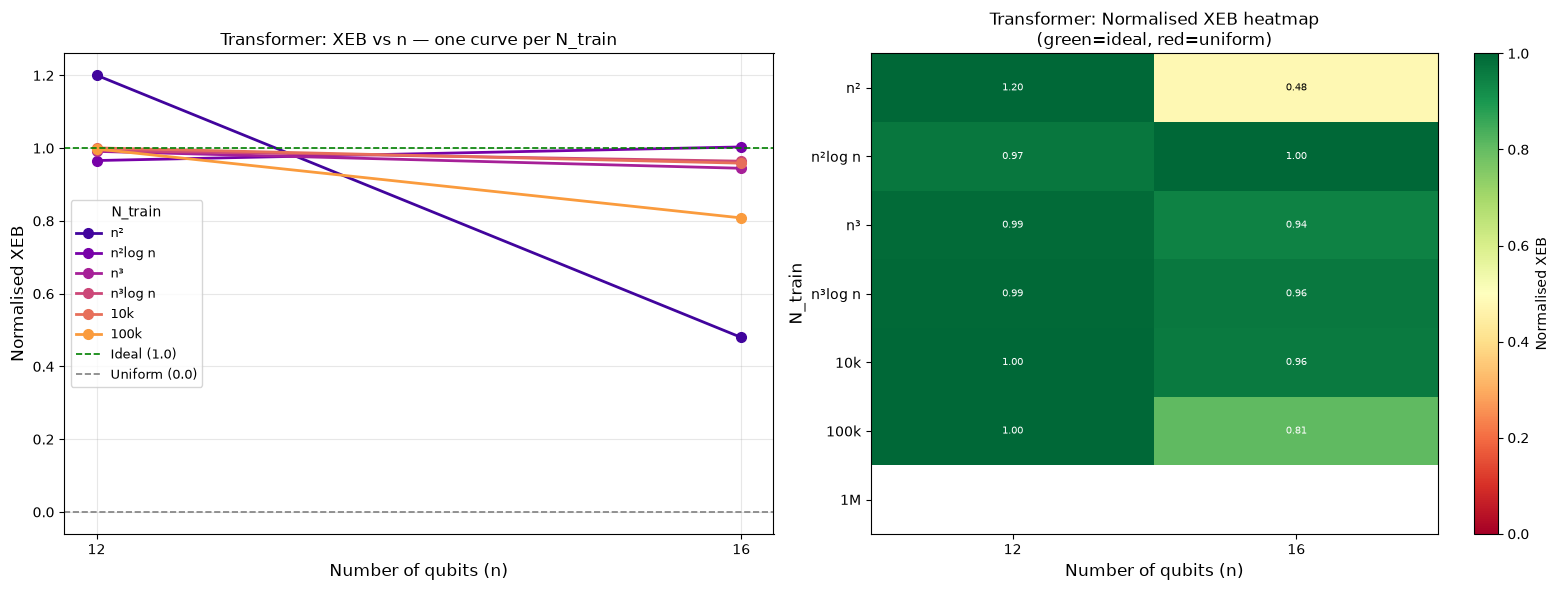

In [ ]:
df_transformer = build_sweep_df(n_sweep_results_transformer)
plot_sweep(df_transformer, 'Transformer', 'transformer_n_qubit_sweep.pdf')

### RNN vs Transformer

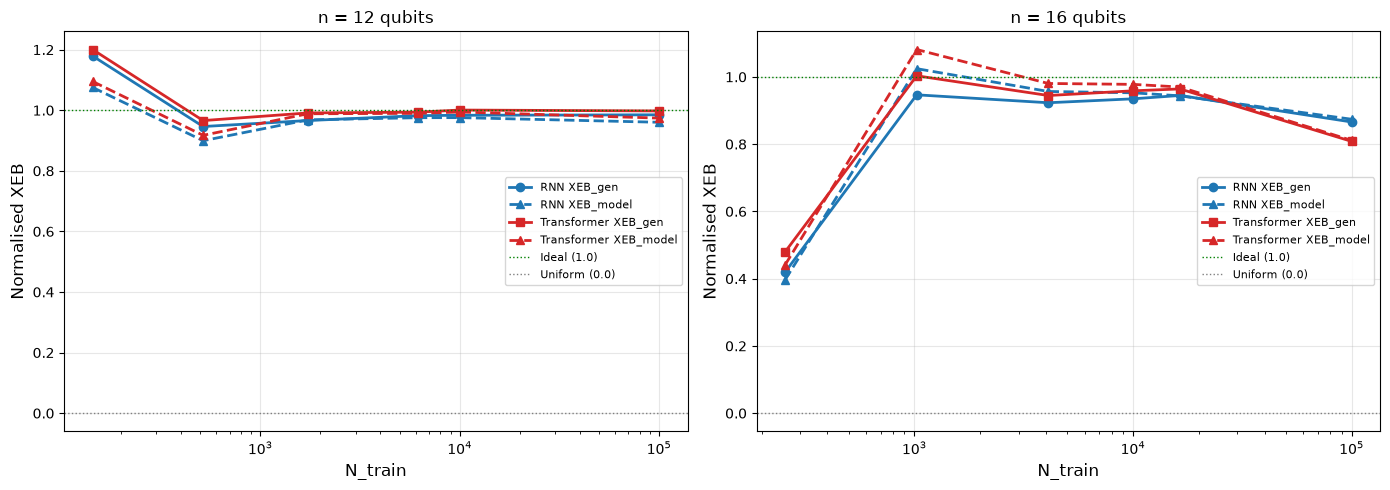

In [ ]:
def plot_comparison(df_rnn, df_transformer, pdf_name):
    n_values = sorted(df_rnn['n_bits'].unique())
    fig, axes = plt.subplots(1, len(n_values), figsize=(7 * len(n_values), 5), squeeze=False)
    axes = axes[0]

    # color = architecture, linestyle/marker = metric (solid o = XEB_gen, dashed ^ = XEB_model)
    series = [
        (df_rnn,         'RNN',         'xeb_gen_norm',   'XEB_gen',   'tab:blue', 'o-'),
        (df_rnn,         'RNN',         'xeb_model_norm', 'XEB_model', 'tab:blue', '^--'),
        (df_transformer, 'Transformer', 'xeb_gen_norm',   'XEB_gen',   'tab:red',  's-'),
        (df_transformer, 'Transformer', 'xeb_model_norm', 'XEB_model', 'tab:red',  '^--'),
    ]

    for ax, n in zip(axes, n_values):
        for df_m, name, metric, metric_label, col, style in series:
            sub = df_m[df_m['n_bits'] == n].sort_values('n_train')
            ax.plot(sub['n_train'], sub[metric], style, color=col, lw=2, ms=6,
                    label=f'{name} {metric_label}')
        ax.axhline(1.0, color='green', ls=':', lw=1.0, label='Ideal (1.0)')
        ax.axhline(0.0, color='grey',  ls=':', lw=1.0, label='Uniform (0.0)')
        ax.set_xscale('log')
        ax.set_xlabel('N_train', fontsize=12)
        ax.set_ylabel('Normalised XEB', fontsize=12)
        ax.set_title(f'n = {n} qubits', fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig(pdf_name)
    plt.show()

plot_comparison(df_rnn, df_transformer, 'rnn_vs_transformer_comparison.pdf')

## Reload from disk

Regenerates all three plots from the pickles saved earlier, without rerunning any training. Needs the imports cell and the `build_sweep_df` / `plot_sweep` / `plot_comparison` definitions above to have been executed (they run fine even if the Experiment sweep cells above them were skipped or errored on missing `n_sweep_results`).

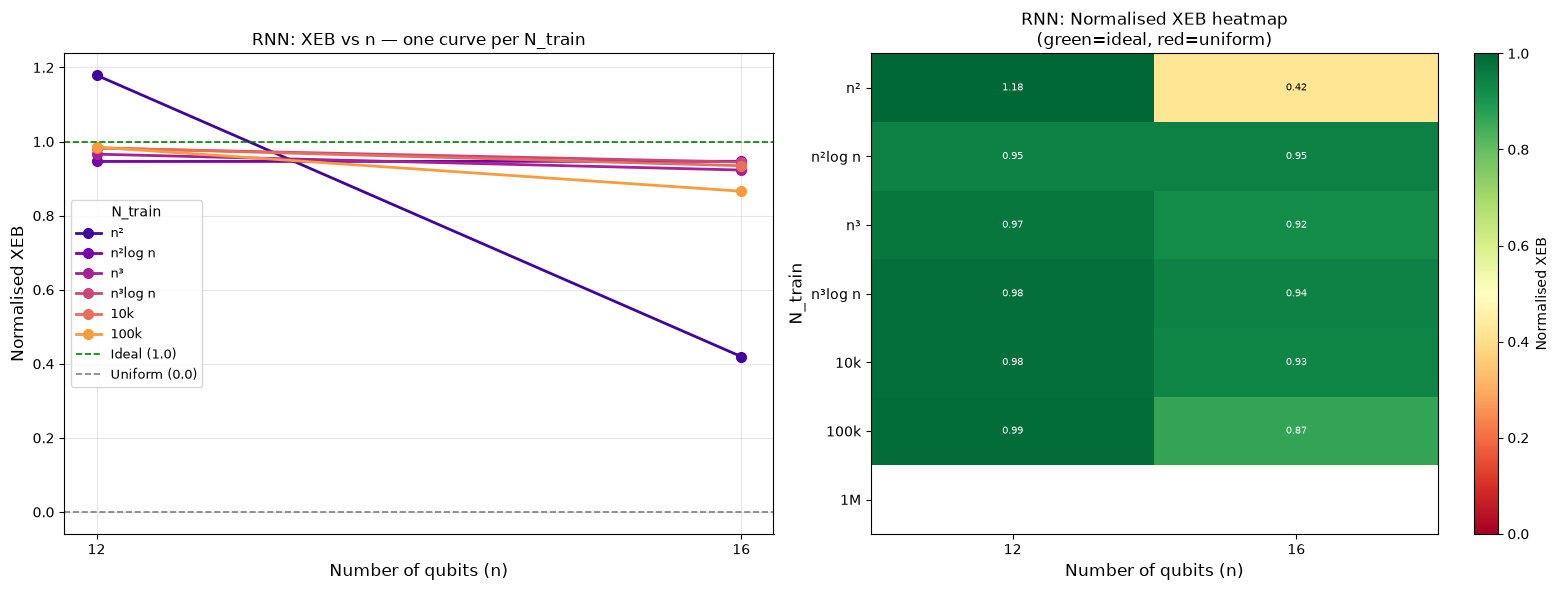

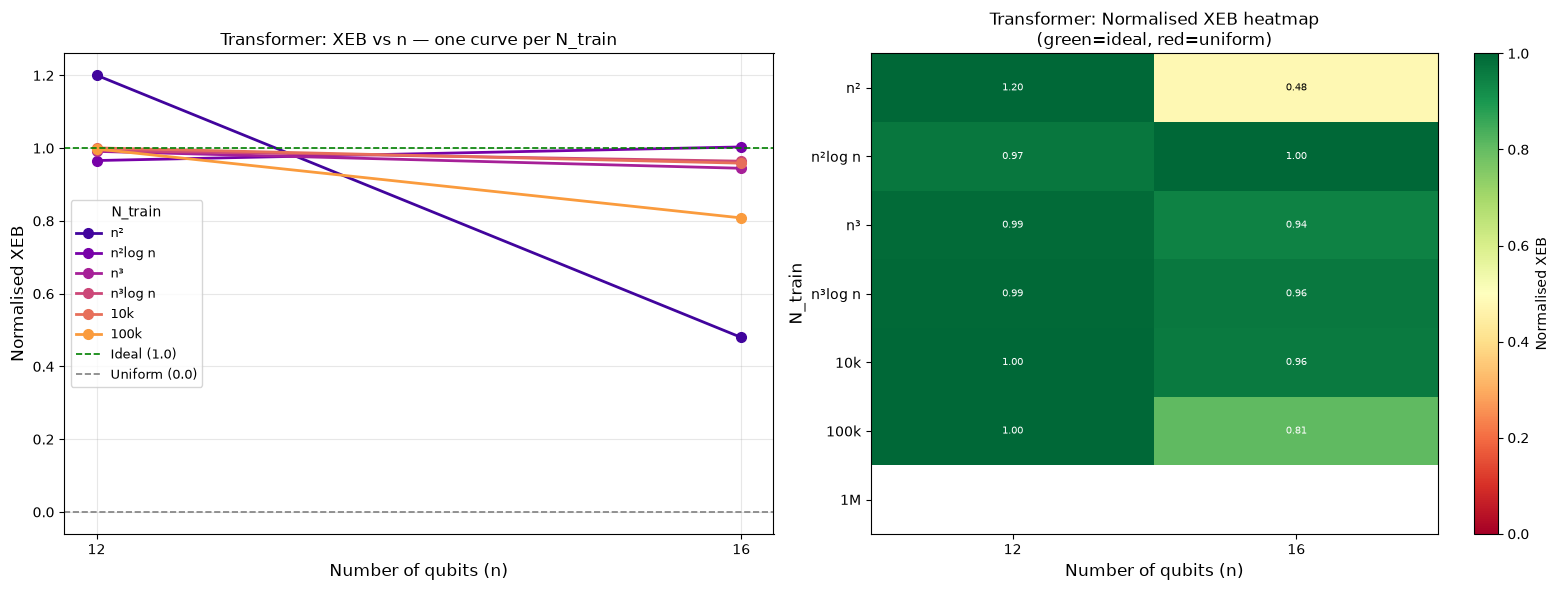

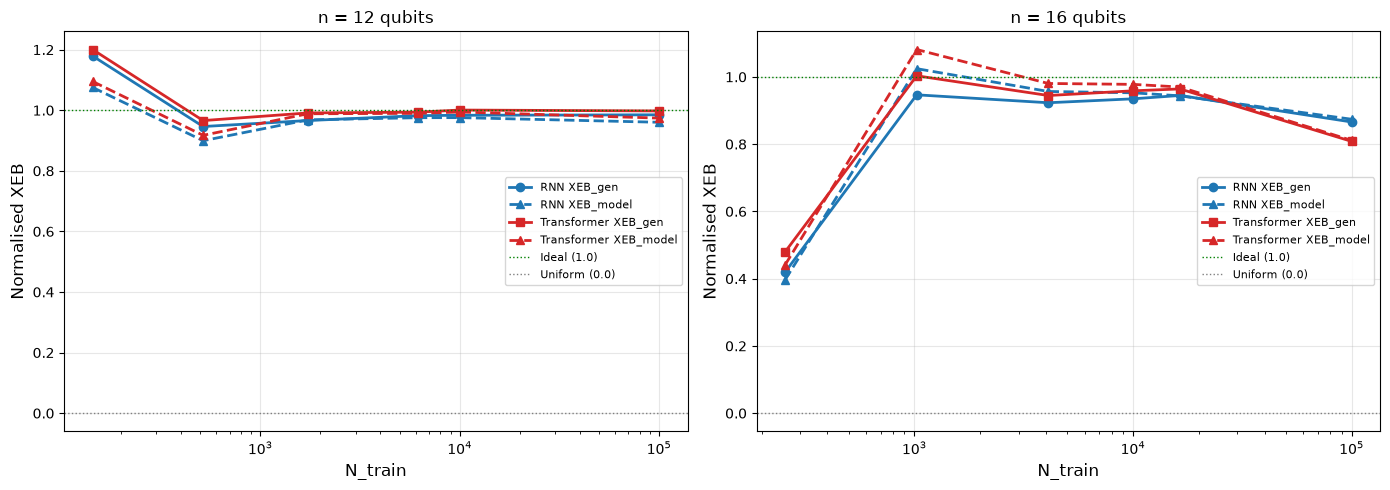

In [ ]:
import pickle
from pathlib import Path

RESULTS_DIR = Path("../results/rnn_vs_transformer")

with open(RESULTS_DIR / "rnn_sweep_results.pkl", "rb") as f:
    n_sweep_results = pickle.load(f)
with open(RESULTS_DIR / "transformer_sweep_results.pkl", "rb") as f:
    n_sweep_results_transformer = pickle.load(f)

df_rnn         = build_sweep_df(n_sweep_results)
df_transformer = build_sweep_df(n_sweep_results_transformer)

plot_sweep(df_rnn, 'RNN', 'rnn_n_qubit_sweep.pdf')
plot_sweep(df_transformer, 'Transformer', 'transformer_n_qubit_sweep.pdf')
plot_comparison(df_rnn, df_transformer, 'rnn_vs_transformer_comparison.pdf')